# Experiments results for transfer learning

Here you will find plots and statistics related to experiments conducted for my thesis. The 2 deep learning model architectures examined are transformer and LSTM.

## Loading the required python packages for processing

Loading global constant variables as well as useful functions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATASET_NAMES = ("iotid20", "usfc-tfc-2016", "IoT-DS2", "CIC-USNW-NB15", "mqtt-iot-ids2020", "ids-2018", "IoT-23")
DATASET_MAP = dict(zip(range(1, len(DATASET_NAMES) + 1), DATASET_NAMES))

def get_models_performance(transformer_csv, lstm_csv):
    transformer_df = pd.read_csv(transformer_csv)
    lstm_df = pd.read_csv(lstm_csv)
    normal_accuracy_per_dataset = pd.DataFrame()
    attack_accuracy_per_dataset = pd.DataFrame()
    for i, dataset_name in DATASET_MAP.items():
        trans_normals_accuracy = transformer_df.loc[(transformer_df["Class"] == 'Normal') & (transformer_df["Fold #"] == i)]["Accuracy"].mean()
        trans_attack_accuracy = transformer_df.loc[(transformer_df["Class"] == 'Attack') & (transformer_df["Fold #"] == i)]["Accuracy"].mean()
        lstm_normals_accuracy = lstm_df.loc[(lstm_df["Class"] == 'Normal') & (lstm_df["Fold #"] == i)]["Accuracy"].mean()
        lstm_attack_accuracy = lstm_df.loc[(lstm_df["Class"] == 'Attack') & (lstm_df["Fold #"] == i)]["Accuracy"].mean()
        normal_accuracy_per_dataset[dataset_name] = [trans_normals_accuracy, lstm_normals_accuracy]
        normal_accuracy_per_dataset["Model"] = ["Transformer", "LSTM"]
        attack_accuracy_per_dataset[dataset_name] = [trans_attack_accuracy, lstm_attack_accuracy]
        attack_accuracy_per_dataset["Model"] = ["Transformer", "LSTM"]

    attack_accuracy_per_dataset = attack_accuracy_per_dataset.set_index("Model")
    normal_accuracy_per_dataset = normal_accuracy_per_dataset.set_index("Model")
    return attack_accuracy_per_dataset, normal_accuracy_per_dataset

## Transfer learning results

The experiments for transfer learning are;
1. Zero shot. One dataset is used for testing, the rest are used for training.
2. Few shot. Unlike zero shot, on training set a few samples are used from testing dataset. For our case, 1000 samples per class

Both experiments were run with the following configurations;
1. All features of datasets. Network specifif features included
2. Network specific features removed

### Zero shot tranfer learning

#### All network features included

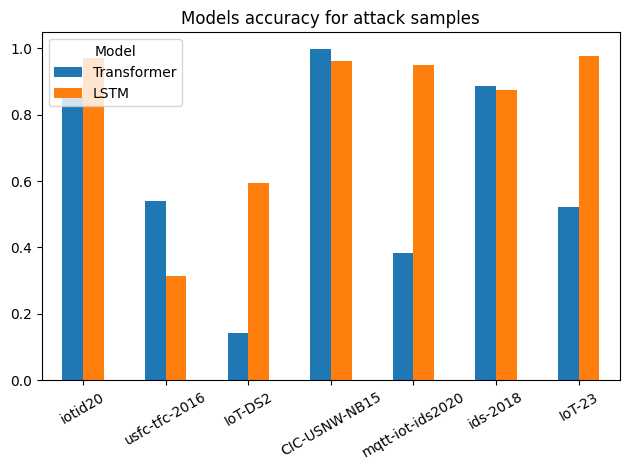

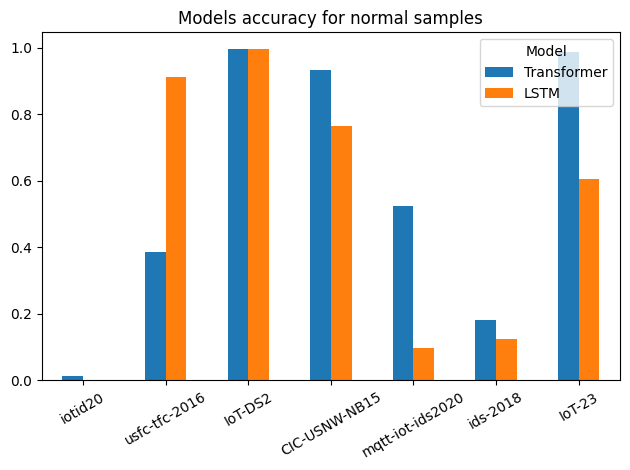

In [2]:
transformer_csv = "../tests/results/reports/transformer/zero_shot/with_network_specific_features/30_epochs_early_stop/results_transformer_TL_zero_shot.csv"
lstm_csv = "../tests/results/reports/lstm/zero_shot/with_network_specific_features/5_epochs_early_stop/results_lstm_TL_zero_shot.csv"
attack_accuracy_per_dataset, normal_accuracy_per_dataset = get_models_performance(transformer_csv, lstm_csv)

ax = attack_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for attack samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("attack-accuracy.pdf")

ax = normal_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for normal samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("normal-accuracy.pdf")



#### Network specific features removed

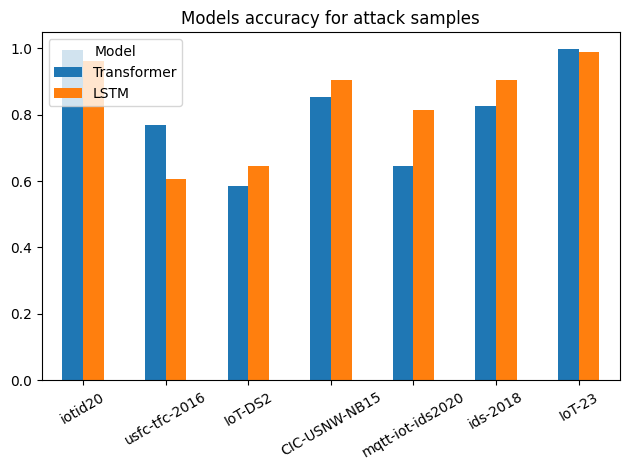

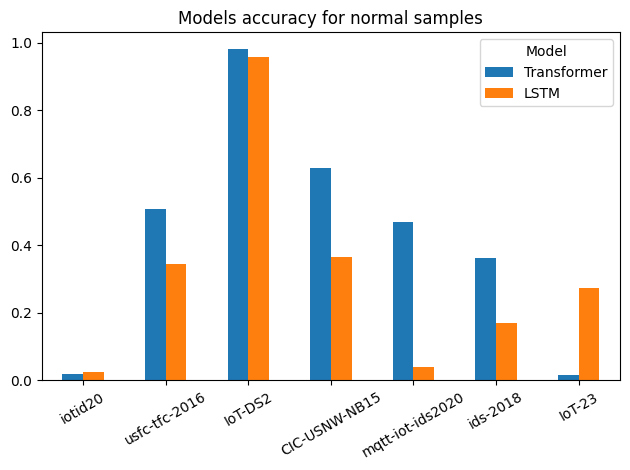

In [3]:
transformer_csv = "../tests/results/reports/transformer/zero_shot/without_network_specific_features_improved/30_epochs_early_stop/results_transformer_TL_removed_zero_shot.csv"
lstm_csv = "../tests/results/reports/lstm/zero_shot/without_network_specific_features_improved/5_epochs_early_stop/results_lstm_TL_removed_zero_shot.csv"
attack_accuracy_per_dataset, normal_accuracy_per_dataset = get_models_performance(transformer_csv, lstm_csv)

ax = attack_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for attack samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("attack-accuracy.pdf")

ax = normal_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for normal samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("normal-accuracy.pdf")

### Few shot transfer learning

#### All network features included


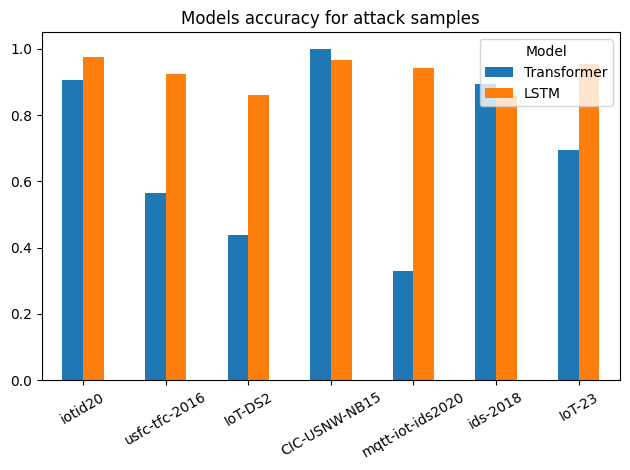

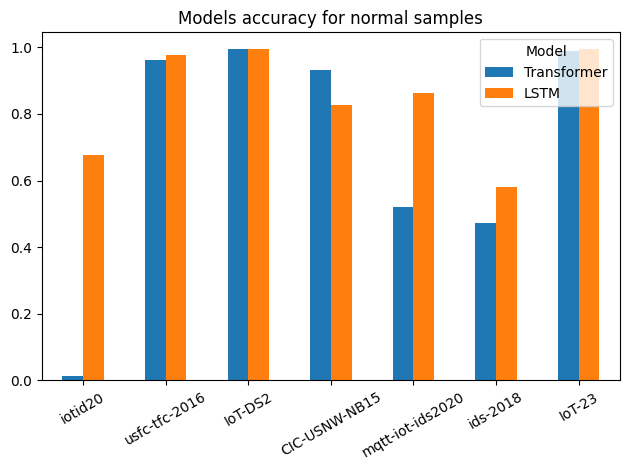

In [4]:
transformer_csv = "../tests/results/reports/transformer/few_shot/1000_samples/with_network_specific_features/30_epochs_early_stop/results_transformer_TL_few_shot.csv"
lstm_csv = "../tests/results/reports/lstm/few_shot/1000_samples/with_network_specific_features/5_epochs_early_stop/results_lstm_TL_few_shot.csv"
attack_accuracy_per_dataset, normal_accuracy_per_dataset = get_models_performance(transformer_csv, lstm_csv)

ax = attack_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for attack samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("attack-accuracy.pdf")

ax = normal_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for normal samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("normal-accuracy.pdf")

#### Without network-specific features

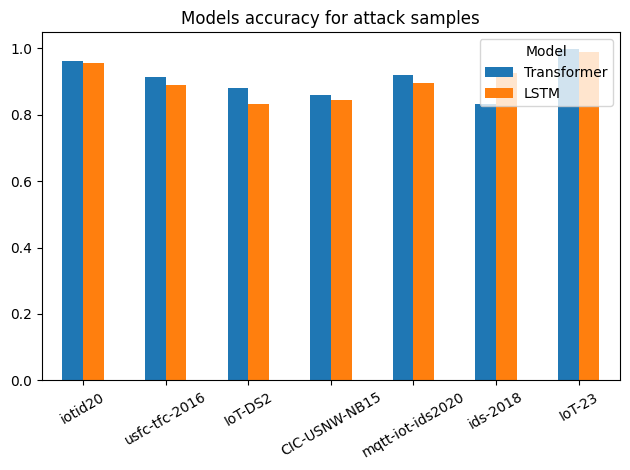

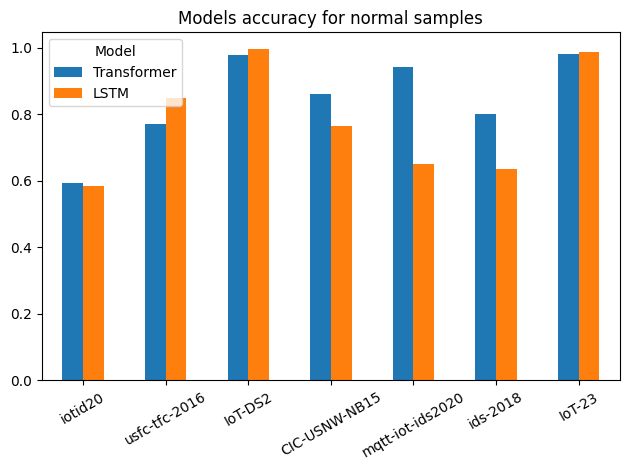

In [5]:
transformer_csv = "../tests/results/reports/transformer/few_shot/1000_samples/without_network_specific_features_improved/30_epochs_early_stop/results_transformer_TL_removed_few_shot.csv"
lstm_csv = "../tests/results/reports/lstm/few_shot/1000_samples/without_network_specific_features_improved/5_epochs_early_stop/results_lstm_TL_removed_few_shot.csv"
attack_accuracy_per_dataset, normal_accuracy_per_dataset = get_models_performance(transformer_csv, lstm_csv)

ax = attack_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for attack samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("attack-accuracy.pdf")

ax = normal_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for normal samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("normal-accuracy.pdf")